# Modelos y Evaluación con el DataFrame Procesado
## 1. Inicialización
Tras haber limpiado y guardado anteriormente el dataset con la imputación y demás la cargamos aquí para poder relaizar la evaluación de nuestro datast y tratar de realizar diversas predicciones de paises.

Para ello antes de entrenar ningún modelo, a parte de lo anterior, añadiremos una columna más que rellenearemos con la información de en qué cluster cae cada pais tras haberlo comprobado con kameans después de la imputación definitiva hecha en `01_Limpieza_y_Tratamiento`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargar los datasets exportados
X_df = pd.read_csv('../dataset/X_vulnerabilidad_info.csv')
y = pd.read_csv('../dataset/y_vulnerabilidad.csv').squeeze() # Lo convertimos en Serie

# 2. Separar metadatos (identificadores) de las variables predictoras puras
id_cols = ['Country Name', 'Country Code', 'Time']
X_features = X_df.drop(columns=id_cols)
metadata = X_df[id_cols].copy()

# 3. Estandarizar las variables predictoras (requisito indispensable para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 4. Aplicar Clustering de Países (K-Means)
# Probemos inicialmente con 4 clústeres (por ejemplo: Bajo, Medio-Bajo, Medio-Alto, Alto desarrollo/vulnerabilidad)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
metadata['Cluster_Pais'] = kmeans.fit_predict(X_scaled)

# 5. Integrar el Clúster como una nueva característica (Feature) en nuestra matriz X
# Convertimos el clúster a variable numérica para que el modelo predictivo pueda leerlo
X_features['Cluster_Pais'] = metadata['Cluster_Pais']

print("¡Clustering de países aplicado con éxito!")
print(metadata['Cluster_Pais'].value_counts())

¡Clustering de países aplicado con éxito!
Cluster_Pais
0    2013
3    1927
1    1520
2    1404
Name: count, dtype: int64


## 2.RandomForest

Como modelo base para inicializar esta evaluación usaremos un RandomForest de modo que se generaran una serie de árboles de decisión los cuales se irán perfeccionando en cada generación hasta

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Definir matriz X (con el nuevo clúster incluido) e y (target)
X_final = X_features.copy()

# 2. Separación de datos: 80% para entrenamiento y 20% para test
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"Dimensiones de entrenamiento (Train): {X_train.shape}")
print(f"Dimensiones de prueba (Test): {X_test.shape}")

# 3. Entrenar el modelo base (Random Forest Regressor)
modelo_base = RandomForestRegressor(random_state=42, n_estimators=100)
modelo_base.fit(X_train, y_train)

# 4. Evaluación inicial rápida
y_pred = modelo_base.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Resultados del Modelo Base ---")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")
print(f"RMSE (Error Cuadrático Medio): {rmse:.4f}")

Dimensiones de entrenamiento (Train): (5491, 55)
Dimensiones de prueba (Test): (1373, 55)

--- Resultados del Modelo Base ---
R² Score (Coeficiente de Determinación): 0.9563
RMSE (Error Cuadrático Medio): 2.8594


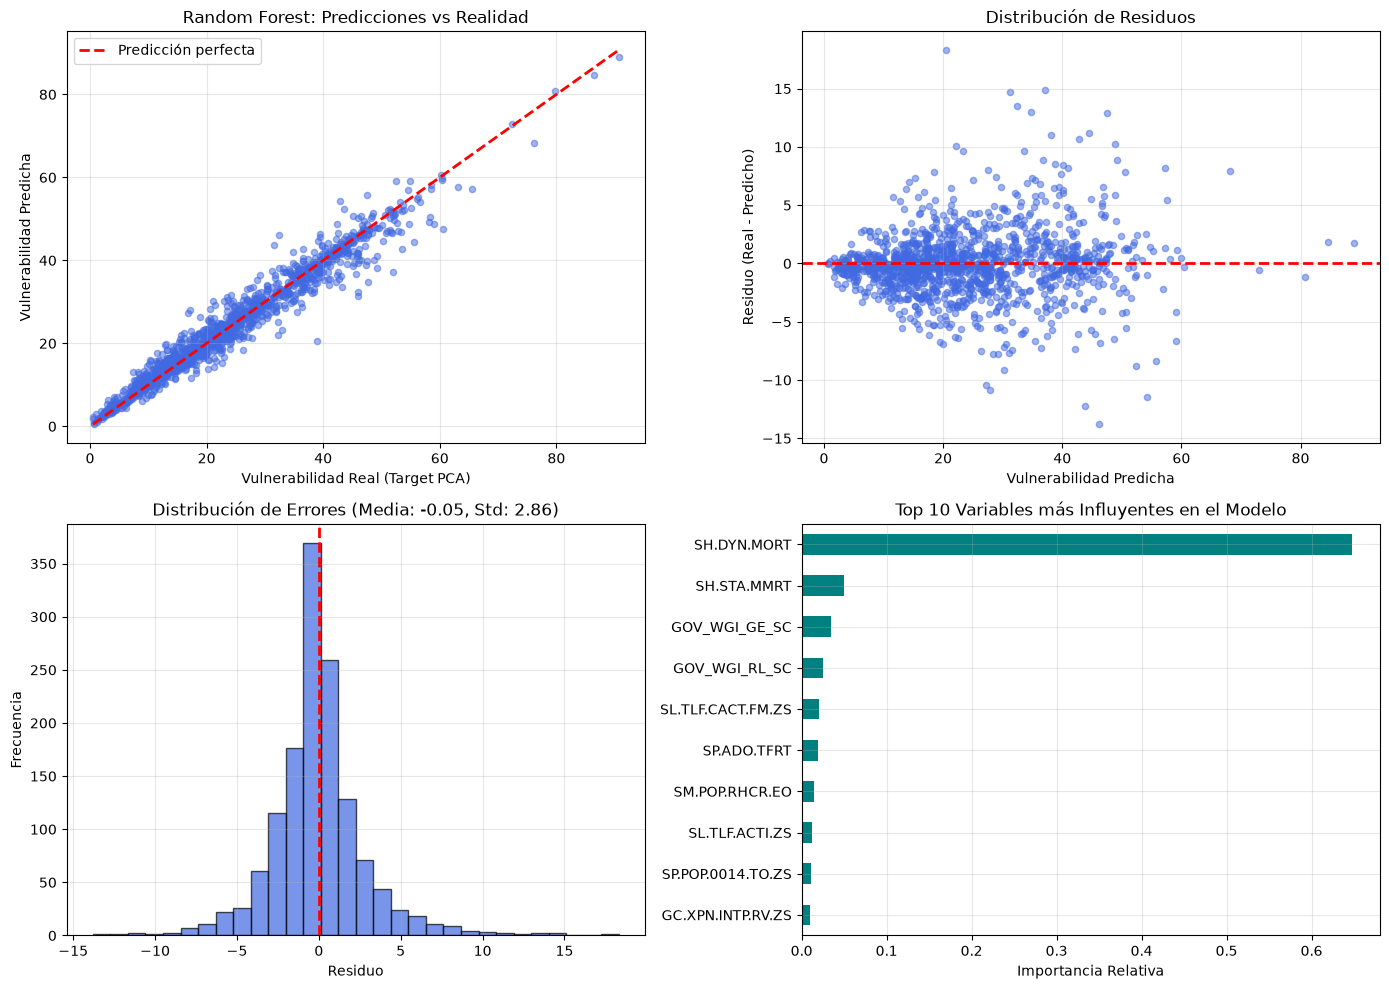

MÉTRICAS DE RENDIMIENTO - RANDOM FOREST
Residuo promedio: -0.0475
Desv. estándar de residuos: 2.8590
R² Score: 0.9563
RMSE: 2.8594
Error porcentual absoluto: 10.35%


In [ ]:
# ============ VISUALIZACIÓN: RANDOM FOREST (VULNERABILIDAD) ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 🔵 GRÁFICA 1 (arriba-izquierda): Predicciones vs Reales
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.5, s=20, color='royalblue')
min_val = np.minimum(y_test.min(), y_pred.min())
max_val = np.maximum(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
ax1.set_xlabel('Vulnerabilidad Real (Target PCA)')
ax1.set_ylabel('Vulnerabilidad Predicha')
ax1.set_title('Random Forest: Predicciones vs Realidad')
ax1.legend()
ax1.grid(alpha=0.3)

# 🔵 GRÁFICA 2 (arriba-derecha): Distribución de Residuos
ax2 = axes[0, 1]
residuos = y_test.to_numpy().flatten() - y_pred.flatten()
ax2.scatter(y_pred, residuos, alpha=0.5, s=20, color='royalblue')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Vulnerabilidad Predicha')
ax2.set_ylabel('Residuo (Real - Predicho)')
ax2.set_title('Distribución de Residuos')
ax2.grid(alpha=0.3)

# 🔵 GRÁFICA 3 (abajo-izquierda): Histograma de Residuos
ax3 = axes[1, 0]
ax3.hist(residuos, bins=30, edgecolor='black', alpha=0.7, color='royalblue')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuo')
ax3.set_ylabel('Frecuencia')
ax3.set_title(f'Distribución de Errores (Media: {residuos.mean():.2f}, Std: {residuos.std():.2f})')
ax3.grid(alpha=0.3)

# 🔵 GRÁFICA 4 (abajo-derecha): Importancia de Variables (Feature Importance)
# Esta sustituye al error porcentual ya que el Target es un índice y aporta un valor analítico brutal para el TFG
ax4 = axes[1, 1]
importancias = pd.Series(modelo_base.feature_importances_, index=X_final.columns)
importancias.nlargest(10).sort_values().plot(kind='barh', ax=ax4, color='teal')
ax4.set_xlabel('Importancia Relativa')
ax4.set_title('Top 10 Variables más Influyentes en el Modelo')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ====================================================================
# IMPRESIÓN DE ESTADÍSTICAS FINALES
# ====================================================================

error_pct_rf = np.abs((y_test.to_numpy().flatten() - y_pred.flatten()) / y_test.to_numpy().flatten() * 100)# Calculamos el error porcentual absoluto

print("====================================================")
print("MÉTRICAS DE RENDIMIENTO - RANDOM FOREST")
print("====================================================")
print(f'Residuo promedio: {residuos.mean():.4f}')
print(f'Desv. estándar de residuos: {residuos.std():.4f}')
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'Error porcentual absoluto: {error_pct_rf.mean():.2f}%')
print("====================================================")

## Primeros resultados
Con esta primera versión de un RandomForest podemos ver un buen resultado ya con una parte explicada de un $95'63$% lo cual ya está genial. Sin embargo trataremos de seguirlo pereccionando ya sea probando otros modelos como el XGBoost y tratando de optimizar los hiperparámetros a ver hasta donde llegamos.